In [20]:
%load_ext autoreload
%autoreload 2

import rasterio

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# spatial
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from shapely.geometry import box

# custom
from src import config
from src.processing import mpkx_loading, processdata
from src.plots import plot_utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load in mpkx file

In [2]:
res = mpkx_loading.process_mpkx(
    config.economics_data_dir / "CR_Fisheries_Shoreline_Protection.mpkx",
    extract_dir=config.economics_data_dir / "test",
    force_reextract=True,
    export_rasters=True,
    save_manifest=True,
)

res["exported_rasters"]
res["manifest_path"]


Extracting CR_Fisheries_Shoreline_Protection.mpkx -> /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/economics/test
Loading vector layers...
  ntl_barrier3_pt: 196131 from asset_ntl3.gdb
  NTL_spared_pos_pts: 350013 from asset_ntl3.gdb
  NTL_R_Fring_DEC: 343094 from asset_ntl3.gdb
  skipped raster_data.gdb (raster geodatabase not supported)
  pop_spared_Pos_PTS: 193629 from point_city.gdb
  GDP_spared_PT: 313487 from good_points.gdb
  POP_R_Fringe_PT: 215332 from good_points.gdb
  POP_R_Barrier_PT: 127155 from good_points.gdb
  GDP_R_Fringe_PT: 344311 from good_points.gdb
  GDP_R_Barrier_PT: 170463 from good_points.gdb
Discovering rasters...
Exporting rasters to GeoTIFF...
Using existing extract at /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/economics/test
  exported raster predcatch -> /Users/rt582/Library/CloudStorage/OneDrive-Unive

PosixPath('/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/economics/test/mpkx_manifest.json')

## Fisheries catch

As described in [Modelling Global Coral Reef Fisheries](https://oceanwealth.org/wp-content/uploads/2025/05/Spalding-et-al-Global-Reef-Fisheries-Final-Report.pdf). Units tons/km2/yr.

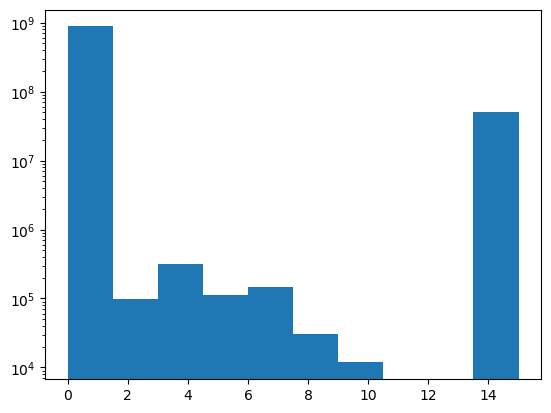

In [ ]:
# open tif
catch_tif = res["exported_rasters"]["predicted_catch"]

# load tif
catch_raster = rasterio.open(catch_tif)
catch_data = catch_raster.read(1)
# plt.hist(catch_data.flatten())    # this shows a random spike at 15 (outside of classes 0-9) which when viewed spatially is clearly an artefact
# plt.yscale("log")

In [ ]:
# cast non-zero raster values to points with x/y coordinates in a GeoDataFrame
rows, cols = np.where(catch_data != 0)
xs, ys = rasterio.transform.xy(catch_raster.transform, rows, cols, offset="center")

pts_gdf = gpd.GeoDataFrame(
    {"value": catch_data[rows, cols]},
    geometry=gpd.points_from_xy(xs, ys),
    crs=catch_raster.crs,
).rename(columns=str.lower)
pts_gdf = pts_gdf.to_crs(epsg=4326)
# remove points above value 9
pts_gdf[pts_gdf["value"] == 15] = np.nan
pts_gdf = pts_gdf.dropna()

# TODO: save to a sensible place

In [ ]:
# map classes to values (page 15). Currently approximating via median. TODO: replace these with exact calculated values
catch_map = {
    0: 0,
    1: np.median((0.1, 1)),
    2: np.median((1.1, 1.5)),
    3: np.median((1.6, 2)),
    4: np.median((2.1, 2.5)),
    5: np.median((2.6, 3)),
    6: np.median((3.1, 3.5)),
    7: np.median((3.6, 4)),
    8: np.median((4.5, 4.1)),
    9: 4.75,  # this one could be far larger
}

pts_gdf["predicted_catch"] = pts_gdf["value"].map(catch_map)
# assign to countries' EEZs
gdf = processdata.assign_points_to_nations(pts_gdf)

  105,839 points (13.06%) unassigned after within-join; filling nearest…


Assigning nearest country via STRtree-enabled nearest-neighbor search: 100%|██████████| 11/11 [00:24<00:00,  2.25s/it]


  810,182/810,182 points assigned to a nation


/Users/rt582/miniforge3/envs/economics-hbb/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


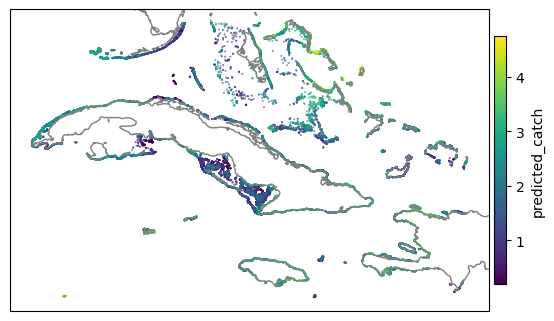

In [6]:
extent = plot_utils.Extent("west_carribbean").as_tuple()

plot_pts_gdf = pts_gdf.cx[extent[0] : extent[2], extent[1] : extent[3]]

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
# Plot without colorbar
im = plot_pts_gdf.plot(
    ax=ax, column="value", cmap="viridis_r", markersize=0.1, legend=False
)
# Add colorbar manually using matplotlib
sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        vmin=plot_pts_gdf["predicted_catch"].min(),
        vmax=plot_pts_gdf["predicted_catch"].max(),
    ),
)
sm._A = []  # Dummy for colorbar
cbar = plt.colorbar(
    sm, ax=ax, orientation="vertical", fraction=0.025, pad=0.01, label="predicted_catch"
)
# plot_utils.format_geo_axes(ax)
ax.add_feature(cfeature.COASTLINE, color="grey")

In [7]:
# TODO: normalise by gdp due to fisheries in this year (2013) to estimate price (assuming linear relationship) for each class

## Coastal protection data

In [35]:
cp_gdf = res["vectors"]["GDP_spared_PT"]
cp_gdf = cp_gdf.to_crs(epsg=4326)
cp_gdf


,pointid,GDP_spared_PT,geometry
0,1,4483,POINT (-64.68657 32.38592)
1,2,4782,POINT (-64.68207 32.38592)
2,3,11476,POINT (-64.67309 32.38592)
3,4,6722,POINT (-64.6686 32.38592)
4,5,139,POINT (-64.69106 32.38059)
...,...,...,...
313482,313483,11,POINT (115.52461 -32.02421)
313483,313484,11,POINT (115.5291 -32.02421)
313484,313485,70,POINT (115.45724 -32.02952)
313485,313486,24,POINT (115.52461 -32.02952)


In [ ]:
cp_gdf = res["vectors"]["GDP_spared_PT"]  # US per km of coastline
cp_gdf = cp_gdf.to_crs(epsg=4326)
cp_gdf.rename(columns={"grid_code": "GDP_spared_PT"}, inplace=True)
cp_gdf.rename(columns=str.lower, inplace=True)

# assign points to nations
cp_gdf = processdata.assign_points_to_nations(cp_gdf)

  159,066 points (50.74%) unassigned after within-join; filling nearest…


Assigning nearest country: 100%|██████████| 16/16 [00:35<00:00,  2.21s/it]

  313,487/313,487 points assigned to a nation


## Tourism


In [ ]:
prices_df = pd.DataFrame(
    {
        "price_bin": [
            "no value",
            "up to 4000",
            "4001-8000",
            "8001-12000",
            "12001-24000",
            "24001-44000",
            "44001-92000",
            "92001-172000",
            "172001-352000",
            "352001-908000",
            ">908000",
        ],
        "price_value": [
            0,
            np.median((0, 4000)),
            np.median((4001, 8000)),
            np.median((8001, 12000)),
            np.median((12001, 24000)),
            np.median((24001, 44000)),
            np.median((44001, 92000)),
            np.median((92001, 172000)),
            np.median((172001, 352000)),
            np.median((352001, 908000)),
            np.median((908001, 1000000)),
        ],
        "price_color": [
            "#828282",  # Bin 0
            "#2892c8",  # Bin 1
            "#74b474",  # Bin 2
            "#52bf81",  # Bin 3
            "#59d95e",  # Bin 4
            "#58f230",  # Bin 5
            "#f6e058",  # Bin 6
            "#e6ac3e",  # Bin 7
            "#d57726",  # Bin 7
            "#bf4713",  # Bin 8
            "#730000",  # Bin 9
        ],
    }
)

price_cmap = ListedColormap(prices_df["price_color"].values)

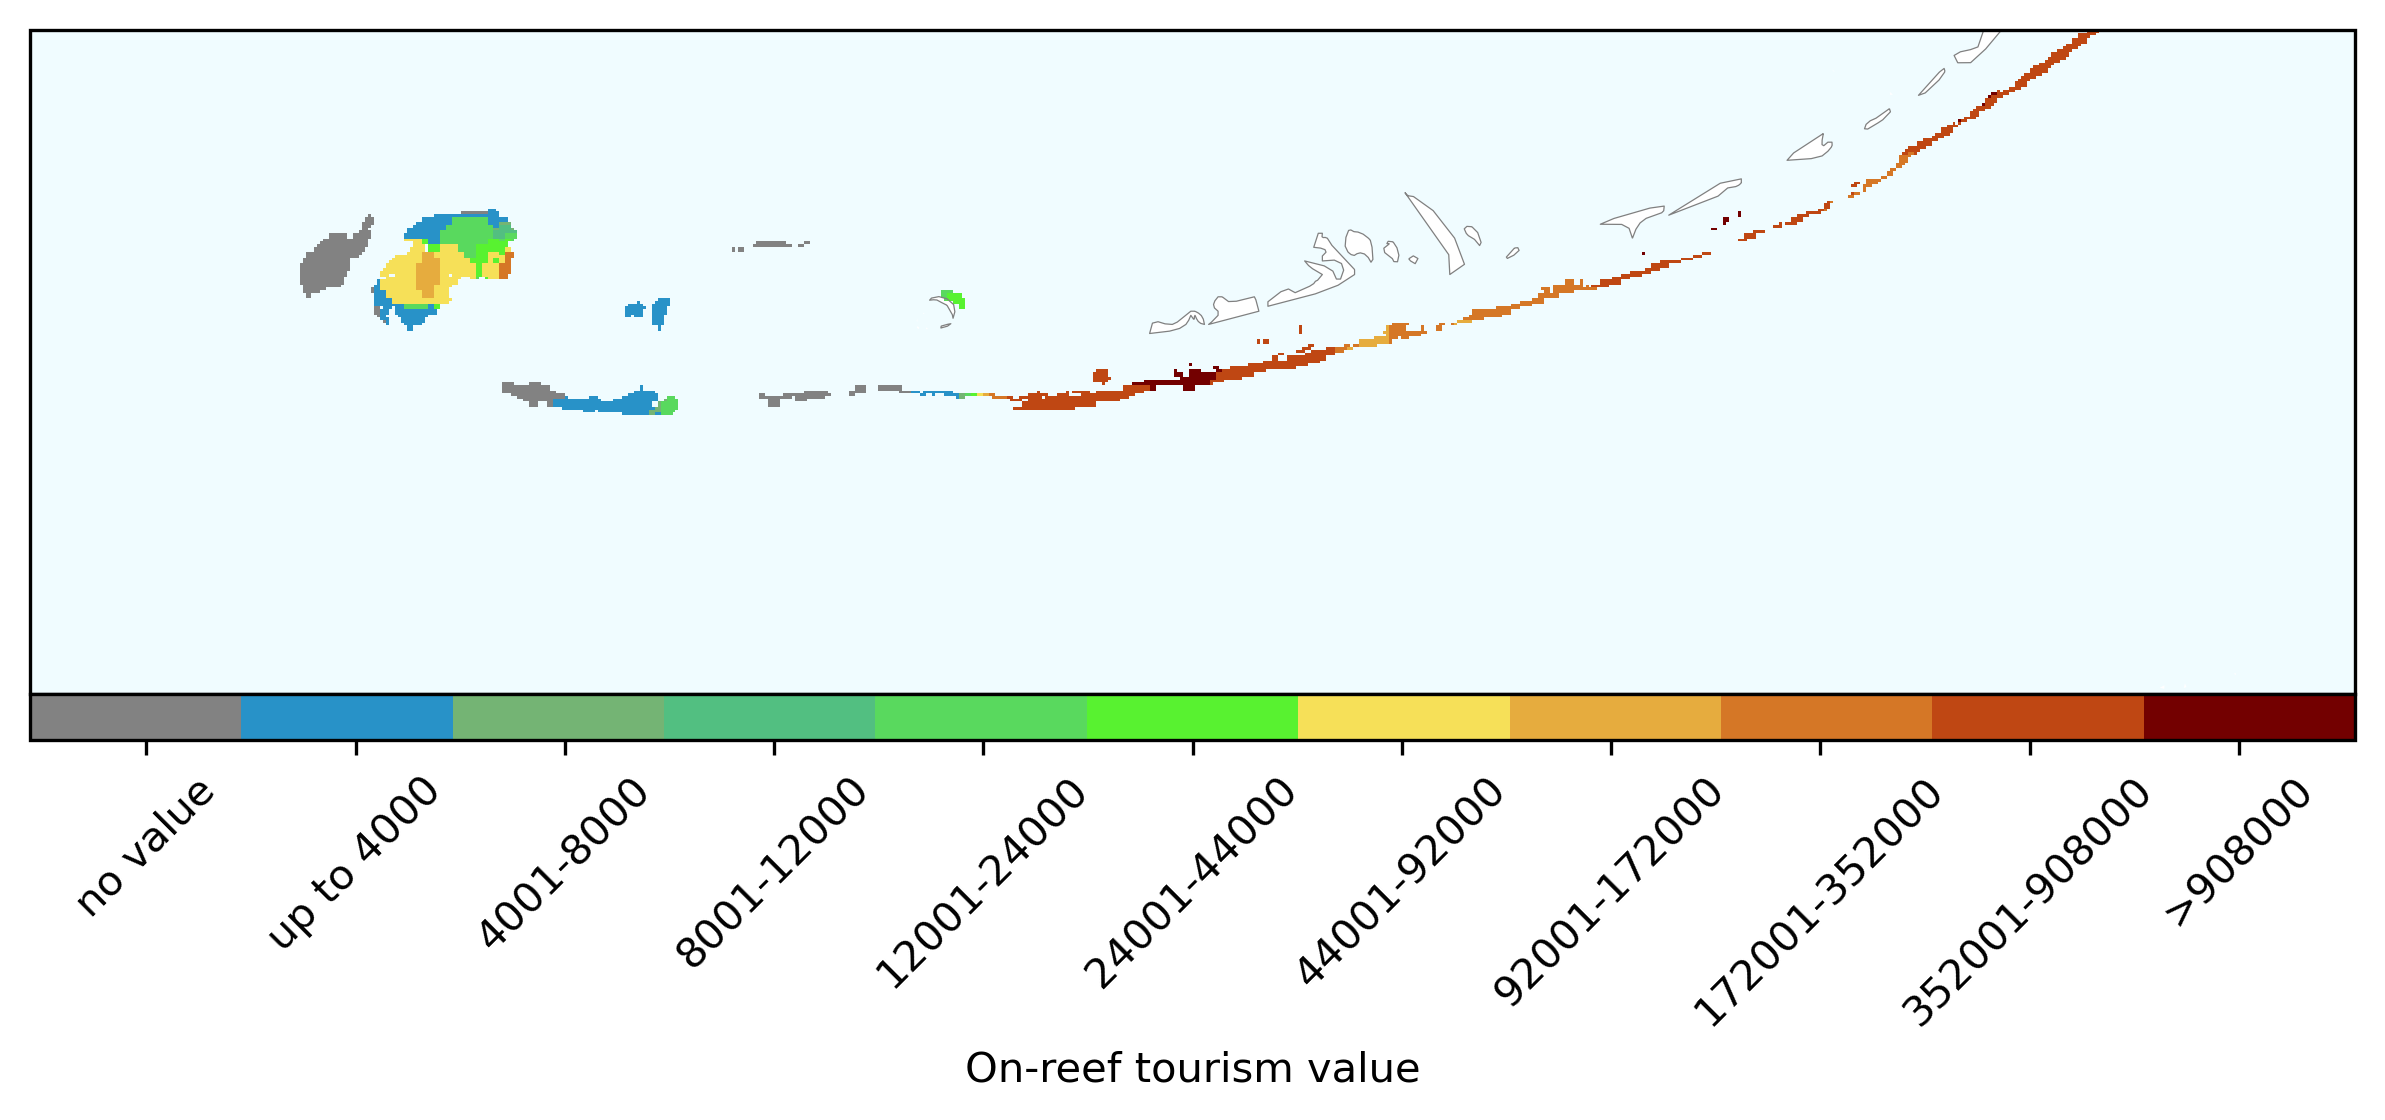

In [42]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm

tourism_gdp_gdf = (
    gpd.read_file(
        config.tourism_dir
        / "total"
        / "Coral_Reef_Tourism_Global_Total_Dollar_Value.shp"
    )
    .to_crs(epsg=4326)
    .rename(columns=str.lower)
)


tourism_gdp_gdf["total_reef_value"] = prices_df["price_value"]
tourism_gdp_gdf["approx_price"] = prices_df["price_value"]

# plot example for florida
fig, ax = plot_utils.generate_geo_axis()
ax = plot_utils.format_geo_axes(ax)

extent = plot_utils.Extent("key_west").as_tuple()

plot_tourism_gdf = tourism_gdp_gdf[tourism_gdp_gdf.geometry.intersects(box(*extent))]

collection = plot_tourism_gdf.plot(
    ax=ax,
    column="bin_global",
    cmap=price_cmap,
    legend=False,  # will create custom legend later
    linewidth=0.2,
    edgecolor=None,
)

norm = Normalize(
    vmin=plot_tourism_gdf["bin_global"].min(),
    vmax=plot_tourism_gdf["bin_global"].max(),
)
sm = cm.ScalarMappable(cmap=price_cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(
    sm,
    ax=ax,
    label="On-reef tourism value",
    orientation="horizontal",
    pad=0,
    aspect=50,
    ticks=np.linspace(0.5, 9.5, len(prices_df["price_value"])),
)
cb.set_ticklabels(prices_df["price_bin"])
cb.ax.tick_params(rotation=45)
# zooming in to compare with the maps online at (Data Layers for Global Recreation and Tourism Coral Reefs) for Ocean Wealth
ax.set_extent(plot_utils.Extent("key_west").as_extent_tuple())
plt.show()

In [45]:
# start by exploding multi-part polygons
tourism_gdp_gdf_exploded = tourism_gdp_gdf.explode(index_parts=False).reset_index(
    drop=True
)
# assign points to nations
tourism_gdp_gdf_exploded = processdata.assign_points_to_nations(
    tourism_gdp_gdf_exploded
)

  26,971 points (42.69%) unassigned after within-join; filling nearest…


Assigning nearest country: 100%|██████████| 3/3 [00:26<00:00,  8.92s/it]

  63,181/63,181 points assigned to a nation


In [ ]:
tourism_gdp_gdf_exploded

,bin_global,sum_gridco,sum_no_cel,sum_sq_km,shape_leng,shape_area,total_reef_value,approx_price,geometry
0,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0,0,"POLYGON ((159.08259 -29.90106, 159.08259 -29.9..."
1,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0,0,"POLYGON ((159.12751 -29.42099, 159.12751 -29.4..."
2,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0,0,"POLYGON ((113.90182 -28.8836, 113.90182 -28.87..."
3,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0,0,"POLYGON ((114.01411 -28.86393, 114.01411 -28.8..."
4,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0,0,"POLYGON ((114.04555 -28.78917, 114.04555 -28.7..."
...,...,...,...,...,...,...,...,...,...
63175,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,908000,908000,"POLYGON ((-64.72817 32.35622, -64.72817 32.352..."
63176,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,908000,908000,"POLYGON ((-64.74614 32.37519, -64.73715 32.375..."
63177,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,908000,908000,"POLYGON ((-64.74614 32.37519, -64.75512 32.375..."
63178,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,908000,908000,"POLYGON ((-64.68326 32.38277, -64.68326 32.378..."


# Unifying datasets

In [51]:
# TODO: work out how to merge point and polygon data for each country. I think it's simple: just more difficult to visualise spatially (may have to superpose the datasets)